In [ ]:
import zipfile
import glob

zip_file = glob.glob("/content/*.zip")[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/TESS")

print("Dataset extracted successfully!")

Dataset extracted successfully!


Dataset exists: True
Total audio files: 5600

Extracting speech features...

Feature extraction completed!
Feature shape: (5600, 40)
Number of labels: 5600
Emotions: [np.str_('angry'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprise'), np.str_('surprised')]

Emotion Distribution:
angry : 800
disgust : 800
fear : 800
happy : 800
neutral : 800
sad : 800
surprise : 400
surprised : 400


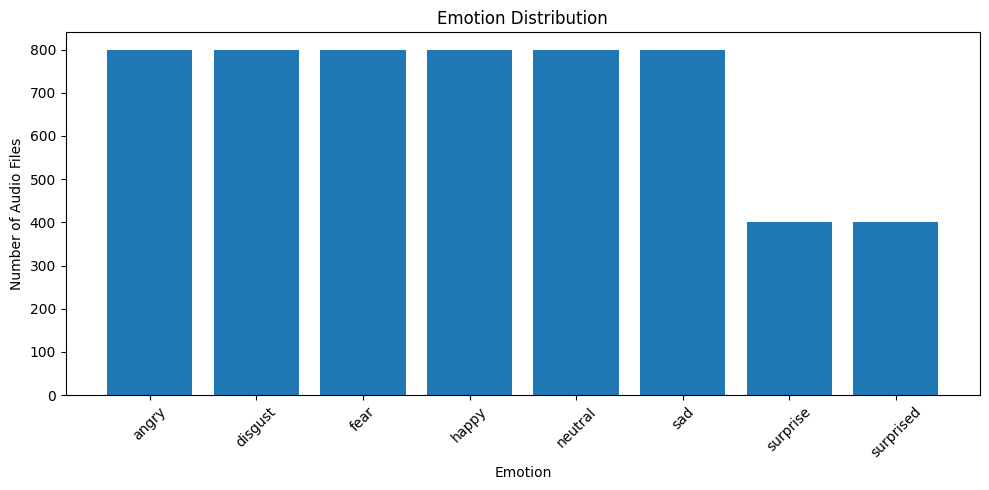

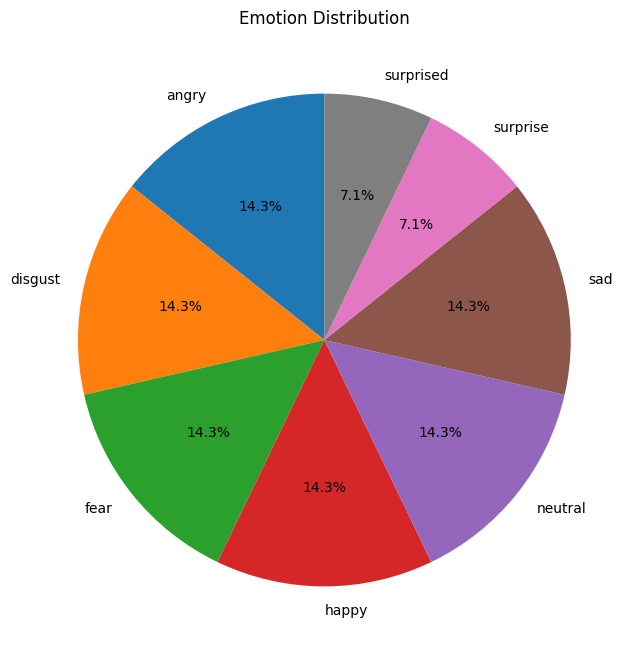

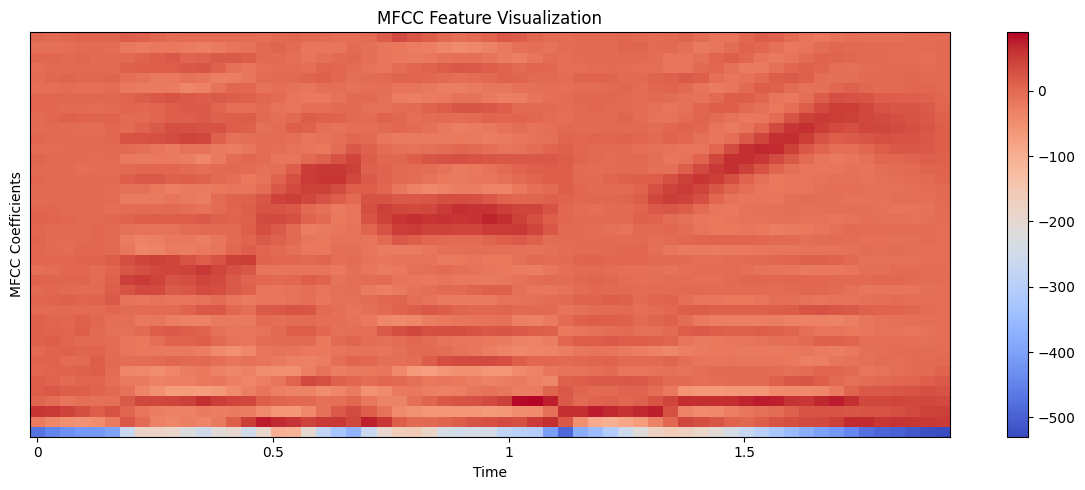


Training samples: 4480
Testing samples: 1120

Training Random Forest model...
Model training completed!

MODEL PERFORMANCE
Accuracy: 100.0 %

Classification Report
--------------------------------------
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00       160
     disgust       1.00      1.00      1.00       160
        fear       1.00      1.00      1.00       160
       happy       1.00      1.00      1.00       160
     neutral       1.00      1.00      1.00       160
         sad       1.00      1.00      1.00       160
    surprise       1.00      1.00      1.00        80
   surprised       1.00      1.00      1.00        80

    accuracy                           1.00      1120
   macro avg       1.00      1.00      1.00      1120
weighted avg       1.00      1.00      1.00      1120



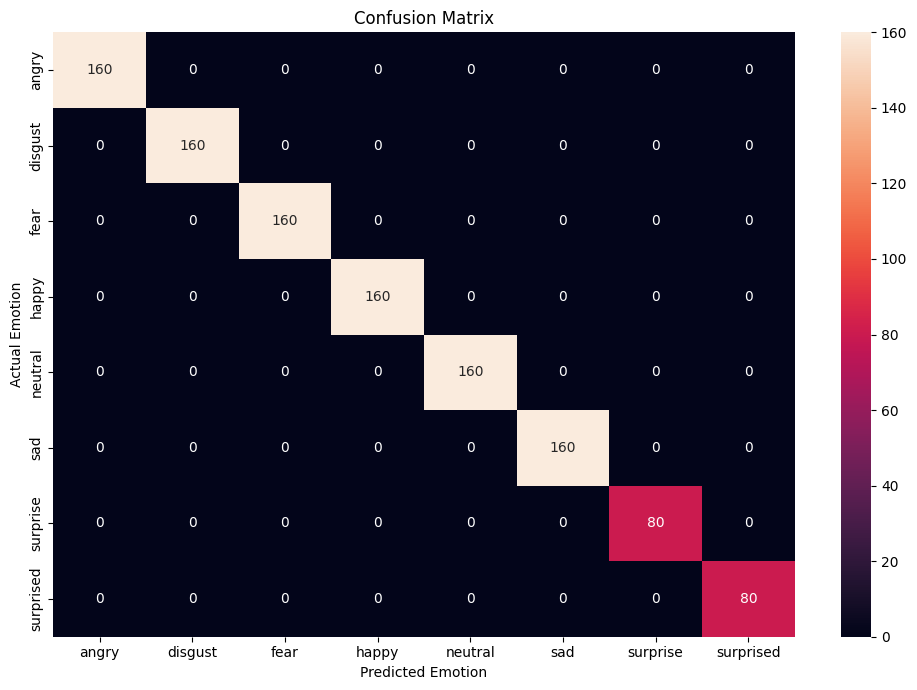

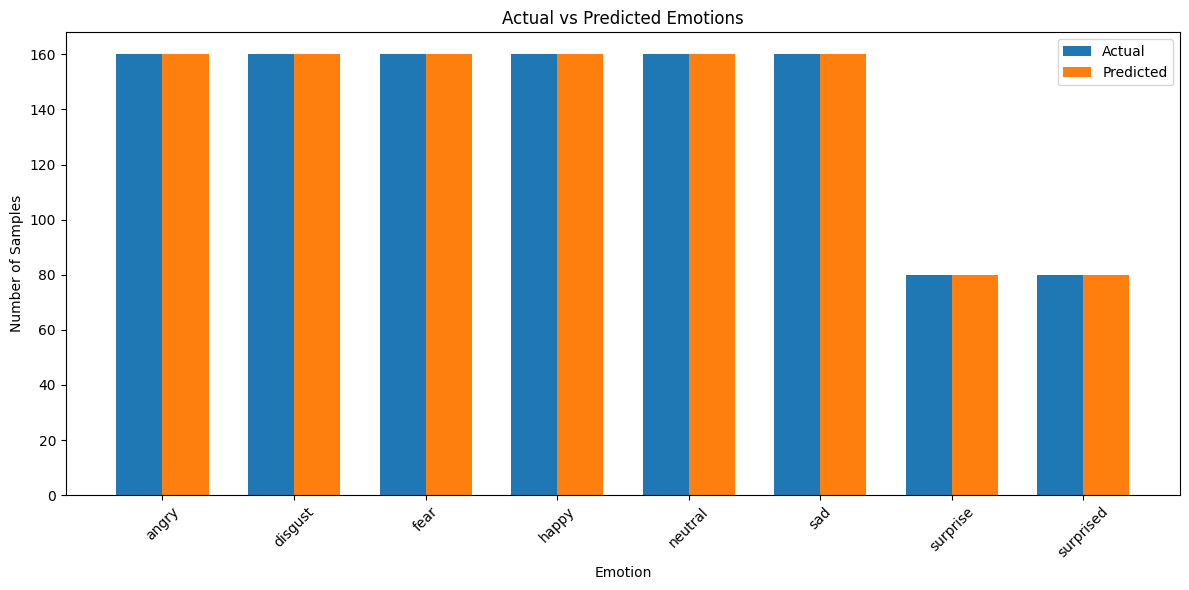

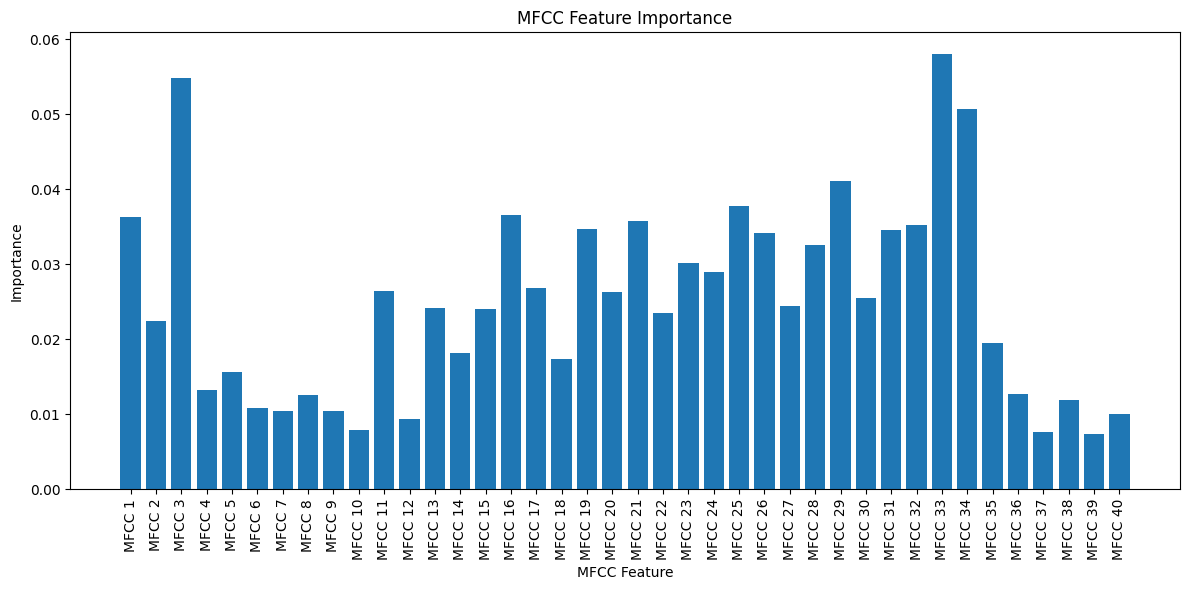


MODEL SAVED
Saved as: /content/emotion_recognition_model.pkl

UPLOAD A WAV FILE FOR TESTING


Saving OAF_book_happy.wav to OAF_book_happy.wav

EMOTION PREDICTION
Audio file: OAF_book_happy.wav
Predicted Emotion: HAPPY


In [ ]:
# ============================================================
# CODEALPHA TASK 2 - EMOTION RECOGNITION FROM SPEECH
# TESS DATASET | FAST VERSION | VISUALIZATIONS
# ============================================================

!pip install librosa scikit-learn matplotlib seaborn joblib -q

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# 1. DATASET
# ============================================================

dataset_path = "/content/TESS"

audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Dataset exists:", os.path.exists(dataset_path))
print("Total audio files:", len(audio_files))


# ============================================================
# 2. FAST MFCC FEATURE EXTRACTION
# ============================================================

def extract_features(file_path):

    try:
        audio, sr = librosa.load(
            file_path,
            sr=16000
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        feature = np.mean(mfcc, axis=1)

        folder = os.path.basename(
            os.path.dirname(file_path)
        )

        emotion = folder.split("_")[-1].lower()

        return feature, emotion

    except Exception:
        return None


print("\nExtracting speech features...")

features = []
labels = []

# Use multiple CPU threads
with ThreadPoolExecutor(max_workers=4) as executor:

    results = list(
        executor.map(
            extract_features,
            audio_files
        )
    )

for result in results:

    if result is not None:

        feature, emotion = result

        features.append(feature)
        labels.append(emotion)


X = np.array(features)
y = np.array(labels)

print("\nFeature extraction completed!")
print("Feature shape:", X.shape)
print("Number of labels:", len(y))
print("Emotions:", sorted(np.unique(y)))


# ============================================================
# 3. EMOTION DISTRIBUTION
# ============================================================

emotions, counts = np.unique(
    y,
    return_counts=True
)

print("\nEmotion Distribution:")

for emotion, count in zip(emotions, counts):
    print(emotion, ":", count)


# ============================================================
# 4. BAR CHART
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    emotions,
    counts
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 5. PIE CHART
# ============================================================

plt.figure(figsize=(8, 8))

plt.pie(
    counts,
    labels=emotions,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Emotion Distribution")

plt.show()


# ============================================================
# 6. MFCC VISUALIZATION
# ============================================================

sample_file = audio_files[0]

audio, sr = librosa.load(
    sample_file,
    sr=16000
)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()

plt.title("MFCC Feature Visualization")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")

plt.tight_layout()
plt.show()


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 8. RANDOM FOREST
# ============================================================

print("\nTraining Random Forest model...")

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Model training completed!")


# ============================================================
# 9. PREDICTION
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n======================================")
print("MODEL PERFORMANCE")
print("======================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report")
print("--------------------------------------")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

emotion_names = sorted(
    np.unique(y)
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=emotion_names
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.tight_layout()
plt.show()


# ============================================================
# 12. ACTUAL VS PREDICTED
# ============================================================

actual = []
predicted = []

for emotion in emotion_names:

    actual.append(
        np.sum(y_test == emotion)
    )

    predicted.append(
        np.sum(y_pred == emotion)
    )

x = np.arange(len(emotion_names))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    actual,
    width,
    label="Actual"
)

plt.bar(
    x + width/2,
    predicted,
    width,
    label="Predicted"
)

plt.title("Actual vs Predicted Emotions")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.xticks(
    x,
    emotion_names,
    rotation=45
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 13. MFCC FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

mfcc_names = [
    "MFCC " + str(i + 1)
    for i in range(40)
]

plt.figure(figsize=(12, 6))

plt.bar(
    mfcc_names,
    importance
)

plt.title("MFCC Feature Importance")
plt.xlabel("MFCC Feature")
plt.ylabel("Importance")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


# ============================================================
# 14. SAVE MODEL
# ============================================================

model_path = "/content/emotion_recognition_model.pkl"

joblib.dump(
    model,
    model_path
)

print("\n======================================")
print("MODEL SAVED")
print("======================================")

print(
    "Saved as:",
    model_path
)


# ============================================================
# 15. FINAL AUDIO TEST
# ============================================================

from google.colab import files

print("\n======================================")
print("UPLOAD A WAV FILE FOR TESTING")
print("======================================")

uploaded = files.upload()

if len(uploaded) > 0:

    audio_file = list(uploaded.keys())[0]

    audio, sr = librosa.load(
        audio_file,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    test_feature = np.mean(
        mfcc,
        axis=1
    ).reshape(1, -1)

    prediction = model.predict(
        test_feature
    )

    print("\n======================================")
    print("EMOTION PREDICTION")
    print("======================================")

    print(
        "Audio file:",
        audio_file
    )

    print(
        "Predicted Emotion:",
        prediction[0].upper()
    )